# White Wine Quality Prediction with Multiclass Kernel Methods

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np 
import time
import matplotlib.pyplot as plt 

## 2. Dataset Loading and Preliminary Inspection

In [2]:
df = pd.read_csv("winequality-white.csv", sep=";")
print(df.head())
print("-" * 111)
print(df.describe())
print("-" * 111)
print(df.nunique())
print("-" * 111)
print(df.duplicated().sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

## 3. Crammer-Singer Multiclass SVM Implementation

In [3]:
# Crammer-Singer 

class CrammerSingerSVM: 
    # (1) Inputs
    def __init__(self, X, y, beta, kernel = "poly", kern_bias = 1.0, gamma = 1.0, d = 3): 
        """Store the training data and model hyperparameters."""
        self.X = np.asarray(X, dtype=float)      
        self.y = np.asarray(y)                   
        self.beta = beta
        self.kernel = kernel
        self.kern_bias = kern_bias
        self.gamma = gamma
        self.d = d
        self.classes = np.sort(np.unique(y))     

    #def poly_kernel(self, Xa=None, Xb=None):
    #    Xa = self.X if Xa is None else np.asarray(Xa, dtype=float)
    #    Xb = self.X if Xb is None else np.asarray(Xb, dtype=float)
    #    return (Xa @ Xb.T + self.kern_bias)**self.d

    def kernel_matrix(self, Xa = None, Xb = None):
        """Return pairwise kernel values between two feature matrices."""
        Xa = self.X if Xa is None else np.asarray(Xa, dtype = float)
        Xb = self.X if Xb is None else np.asarray(Xb, dtype = float)

        if self.kernel == "linear":
            return Xa @ Xb.T + self.kern_bias

        if self.kernel == "poly":
            return (self.gamma * (Xa @ Xb.T) + self.kern_bias)** self.d

        if self.kernel in ("rbf", "laplacian"):
            if self.kernel == "rbf": 
                sa = np.einsum('ij,ij->i', Xa, Xa)
                sb = np.einsum('ij,ij->i', Xb, Xb)
                D2 = sa[:, None] + sb[None, :] - 2.0 * (Xa @ Xb.T)
                return np.exp(-self.gamma * np.maximum(D2, 0.0))
            D1 = np.abs(Xa[:, None, :] - Xb[None, :, :]).sum(-1)
            return np.exp(-self.gamma * D1)
        if self.kernel == "sigmoid": 
            return np.tanh(self.gamma * (Xa @ Xb.T) + self.kern_bias)

        raise ValueError(f"unknown kernel: {self.kernel}")
    
    # (2) Initialise
    def initialiser(self):
        """Initialise the dual variables, kernel matrix and score matrix."""
        m = self.X.shape[0]
        k = len(self.classes)
        self.m, self.k = m, k

        self.E = (self.classes[None, :] == self.y[:, None]).astype(float)   # m x k, delta
        self.bar_tau = np.zeros((m, k))
        self.F = -self.beta * self.E
        self.K = self.kernel_matrix()
        self.A = np.diag(self.K).copy()
        if (self.A <= 0).any():
            raise ValueError(f"{(self.A<=0).sum()} non-positive diagonal entries — kernel not PSD here")
        return self.F

    # (3) Repeat 
    def psi(self):
        """Return the optimality-condition violation for every training example."""
        return self.F.max(1) - np.where(self.bar_tau < self.E - 1e-12, self.F, np.inf).min(1)

    def select_p(self):
        """Return the index with the largest optimality violation."""
        p = np.argmax(self.psi)
        return int(p)

    def reduced_prob(self):
        """Construct the reduced optimisation problem for the selected example."""
        D = self.F[self.p]/self.A[self.p] - self.bar_tau[self.p] + self.E[self.p]
        theta = D.sum()/self.k - 1.0/self.k
        return D, theta 

    def FixedPointAlg(self, epsilon):
        """Solve the reduced problem using the Crammer-Singer fixed-point iteration."""
        D = self.D
        theta = self.theta
        while True:
            theta_new = np.maximum(theta, D).sum()/self.k - 1.0/self.k
            if abs(theta - theta_new) <= epsilon * max(1.0, abs(theta)):
                break
            theta = theta_new
        return np.minimum(theta_new - D, 0.0) + self.E[self.p]
    
    def difference(self):
        """Return the required change in the selected dual-variable row."""
        return self.tau_star - self.bar_tau[self.p]

    # ? 
    def update_F(self):
        """Update the score matrix F after the dual-variable change."""
        self.F += np.outer(self.K[self.p], self.dtau)

    # ? 
    def commit(self):
        """Store the updated dual variables for the selected example."""
        self.bar_tau[self.p] = self.tau_star

    def predict(self, X_test):
        """Predict class labels for a matrix of observations."""
        Ktest  = self.kernel_matrix(X_test, self.X)    # q x m
        scores = Ktest @ self.bar_tau                # q x k
        return self.classes[np.argmax(scores, axis=1)]

    def fit(self, epsilon=0.1, max_rounds=300_000, inner_eps=1e-10, trace_every=1000):
        """Fit the model until convergence or the maximum number of rounds."""
        self.initialiser()
        self.trace = []
        tol = epsilon * self.beta
        for t in range(max_rounds):
            psi = self.psi()
            self.p = int(np.argmax(psi))
            if trace_every and t % trace_every == 0:
                self.trace.append((t, float(psi[self.p])))
            if psi[self.p] < tol:
                self.converged = True
                break
            self.D, self.theta = self.reduced_prob()
            self.tau_star = self.FixedPointAlg(inner_eps)
            self.dtau = self.difference()
            self.update_F()
            self.commit()
        else:
            self.converged = False
        self.rounds = t
        self.final_psi = float(psi[self.p])
        return self


## 4. NumPy Data Utilities and Evaluation Metrics

In [4]:
# sklearn alternative metrics

def train_test_split_np(X, y, test_size = 0.2, seed = 42):
    """Stratified split: each class contributes the same proportion to the test set"""
    rng = np.random.default_rng(seed)
    test_idx = []
    for c in np.unique(y):
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_test = int(round(test_size * len(idx)))
        test_idx.append(idx[:n_test])
    test_idx = np.sort(np.concatenate(test_idx))
    train_idx = np.setdiff1d(np.arange(len(y)), test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardise(X_train, X_test): 
    """z-score using Train statistics only (no leakage)"""
    mu, sd = X_train.mean(axis = 0), X_train.std(axis = 0)
    sd[sd == 0] = 1.0

    return (X_train - mu)/sd, (X_test - mu)/sd

def accuracy(y_true, y_pred):
    """Return the proportion of correctly predicted labels."""
    return np.mean(y_true == y_pred)

def mae(y_true, y_pred):
    """Return the mean absolute error between observed and predicted scores."""
    return np.mean(np.abs(y_true - y_pred))

def within_one(y_true, y_pred):
    """Return the proportion of predictions within one quality category."""
    return np.mean(np.abs(y_true - y_pred) <= 1)

def per_class_scores(y_true, y_pred):
    """Return precision, recall, F1 and support for every observed class."""
    out = {}
    for c in np.union1d(np.unique(y_true), np.unique(y_pred)): 
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))

        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        out[c] = (prec, rec, f1, int(np.sum(y_true == c)))
        
    return out 

def macro_f1(y_true, y_pred): 
    """Return the unweighted mean of the class-specific F1 scores."""
    return np.mean([v[2] for v in per_class_scores(y_true, y_pred).values()])

def classification_table(y_true, y_pred): 
    """Print class-specific and aggregate classification metrics."""
    print(f"{'class':>6}{'precision':>11}{'recall':>9}{'f1':>8}{'support':>9}")
    for c, (p, r, f, s) in per_class_scores(y_true, y_pred).items():
        print(f"{c:>6}{p:>11.2f}{r:>9.2f}{f:>8.2f}{s:>9}")
    print(f"\n accuracy {accuracy(y_true, y_pred):.4f}"
          f" macro F1 {macro_f1(y_true, y_pred):.4f}"
          f" MAE {mae(y_true, y_pred):.4f}"
          f" within ±1 {within_one(y_true, y_pred):.4f}")

## 5. Dataset Analysis

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    3961.000000       3961.000000  3961.000000     3961.000000   
mean        6.839346          0.280538     0.334332        5.914819   
std         0.866860          0.103437     0.122446        4.861646   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.600000   
50%         6.800000          0.260000     0.320000        4.700000   
75%         7.300000          0.330000     0.390000        8.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  3961.000000          3961.000000           3961.000000  3961.000000   
mean      0.045905            34.889169            137.193512     0.993790   
std       0.023103            17.210021             43.129065     0.002905   
min       0.009000             2.000000         

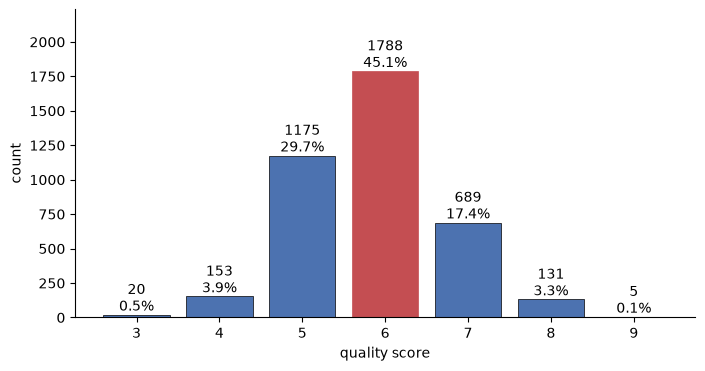

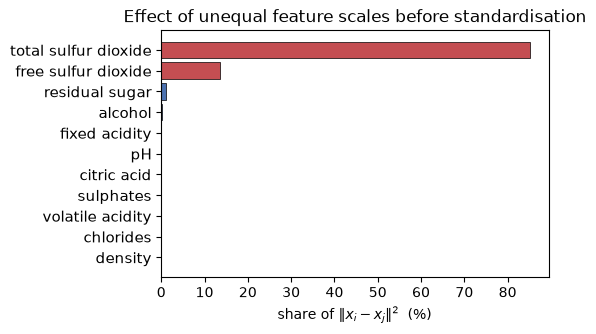

In [12]:
# Analysis 

clean = df.drop_duplicates()
X = clean.drop(columns="quality").to_numpy()
y = clean["quality"].to_numpy()

# (1) Feature summary table 
print(clean.describe())
print("-" * 111)

# (2) Correlation matrix (X vs. "quality")
print(f"Correlation matrix (X vs. 'quality'):")
print(clean.corrwith(other = clean["quality"]))
print("-" * 111)

# (3) Multicollinearity
corr = clean.drop(columns="quality").corr()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).stack().sort_values(key=abs, ascending=False)
strongest = pairs.head(6).rename_axis(["feature_1", "feature_2"]).reset_index(name = "correlation")
print("Strongest feature-feature correlations:")
print(strongest.to_string(index=False, formatters={"correlation": "{:.3f}".format}))
print("-" * 111)
def vif(Xdf):
    """Variance inflation factor: 1/(1-R^2) from regressing each feature on the rest."""
    out = {}
    for col in Xdf.columns:
        yv = Xdf[col].to_numpy()
        Xv = np.column_stack([np.ones(len(Xdf)), Xdf.drop(columns=col).to_numpy()])
        beta, *_ = np.linalg.lstsq(Xv, yv, rcond=None)
        r2 = 1 - ((yv - Xv @ beta)**2).sum() / ((yv - yv.mean())**2).sum()
        out[col] = 1.0 / (1.0 - r2)
    return pd.Series(out).sort_values(ascending=False)

print("\nVIF (>10 indicates severe multicollinearity):")
print(vif(clean.drop(columns="quality")).round(2).to_string())
print("-" * 111)


# (4) 1-NN Separability
Xs = (X - X.mean(0)) / X.std(0)
sq = np.einsum('ij,ij->i', Xs, Xs)
D2 = sq[:,None] + sq[None,:] - 2*(Xs @ Xs.T); np.fill_diagonal(D2, np.inf)
nn = y[D2.argmin(1)]
print(f"1-NN agreement {np.mean(nn==y):.3f}   within ±1 {np.mean(np.abs(nn-y)<=1):.3f}")
print("-" * 111)

# Target Distribution and Class Imbalance
counts = pd.Series(y).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="k", lw=.5)

bars[counts.values.argmax()].set_color("#C44E52")
for k, v in counts.items():
    ax.text(k, v + 30, f"{v}\n{v/counts.sum():.1%}", ha="center", fontsize = 10)
    
ax.set_xlabel("quality score"); ax.set_ylabel("count")
ax.set_ylim(0, counts.max()*1.25); ax.spines[['top','right']].set_visible(False)

# Effect of Unequal Feature Scales
std = X.std(0)                      # X BEFORE standardise()
share = (2*std**2) / (2*std**2).sum()
order = np.argsort(share)
names = clean.drop(columns="quality").columns

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.barh(range(len(names)), share[order]*100,
        color=["#C44E52" if s>.1 else "#4C72B0" for s in share[order]], edgecolor="k", lw=.5)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names[order], fontsize=11)
ax.set_xlabel(r"share of $\|x_i-x_j\|^2$  (%)")
ax.set_title("Effect of unequal feature scales before standardisation")


# Duplicate leakage: what deduplication actually removes
Xd = df.drop(columns="quality").to_numpy(); yd = df["quality"].to_numpy()
Xa, Xb, ya, yb = train_test_split_np(Xd, yd, 0.2, seed=42)
tr = set(map(tuple, Xa.round(9)))
leak = np.array([tuple(r) in tr for r in Xb.round(9)])
print(f"{df.duplicated().sum()} duplicate rows of {len(df)}")
print(f"test rows with an exact twin in train: {leak.sum()}/{len(leak)} = {leak.mean():.1%}")

## 6. Preliminary Comparison of SVM Configurations

In [6]:
X_train, X_test, y_train, y_test = train_test_split_np(X, y, test_size=0.2, seed=42)
X_train, X_test = standardise(X_train, X_test)          # (1) replaces StandardScaler

def score(y_true, y_pred):                               # (2) own metrics
    return dict(acc=accuracy(y_true, y_pred),
                mF1=macro_f1(y_true, y_pred),
                MAE=mae(y_true, y_pred),
                within1=within_one(y_true, y_pred))

CONFIGS = [
    dict(kernel="linear", kern_bias=1.0),
    dict(kernel="poly",   kern_bias=1.0, gamma=1.0, d=2),
    dict(kernel="poly",   kern_bias=1.0, gamma=1.0, d=3),
    dict(kernel="poly",   kern_bias=1.5, gamma=1.0, d=4),
    dict(kernel="rbf",    gamma=0.05),
    dict(kernel="rbf",    gamma=1/11),
    dict(kernel="rbf",    gamma=0.2),
    dict(kernel="rbf",    gamma=0.5),
]

rows, models = [], []
for cfg in CONFIGS:
    t0 = time.perf_counter()
    mdl = CrammerSingerSVM(X_train, y_train, beta=1.1, **cfg).fit(
        epsilon=0.3, max_rounds=1_000_000)
    models.append(mdl)
    rows.append({**cfg,
                 "conv": mdl.converged, "rounds": mdl.rounds, "psi": mdl.final_psi,
                 **score(y_test, mdl.predict(X_test)),
                 "sec": time.perf_counter() - t0})

table = pd.DataFrame(rows).round(4)
display(table.fillna("—"))

# (3) per-class breakdown for the winner
best = table[table.conv].sort_values("acc", ascending=False).index[0]
print(f"\nBest converged: {CONFIGS[best]}")
classification_table(y_test, models[best].predict(X_test))

,kernel,kern_bias,conv,rounds,psi,acc,mF1,MAE,within1,sec,gamma,d
0,linear,1.0,True,98910,0.3283,0.5296,0.1777,0.5460,0.9294,27.7988,—,—
1,poly,1.0,False,999999,2.2013,0.4704,0.2375,0.6419,0.9092,254.7519,1.0,2.0
2,poly,1.0,False,999999,2.2149,0.3581,0.1851,0.7919,0.8714,245.9437,1.0,3.0
3,poly,1.5,False,999999,4.2418,0.4439,0.2372,0.6860,0.8890,239.9526,1.0,4.0
4,rbf,—,True,5597,0.3178,0.5599,0.2590,0.5044,0.9445,2.0722,0.05,—
5,rbf,—,True,5517,0.3182,0.5574,0.2590,0.5107,0.9420,1.9556,0.0909,—
6,rbf,—,True,5151,0.3294,0.5473,0.2773,0.5183,0.9445,1.8238,0.2,—
7,rbf,—,True,4495,0.3287,0.5397,0.2758,0.5259,0.9433,1.5382,0.5,—



Best converged: {'kernel': 'rbf', 'gamma': 0.05}
 class  precision   recall      f1  support
     3       0.00     0.00    0.00        4
     4       0.44     0.13    0.20       31
     5       0.55     0.58    0.57      235
     6       0.56     0.72    0.63      358
     7       0.59     0.32    0.41      138
     8       0.00     0.00    0.00       26
     9       0.00     0.00    0.00        1

 accuracy 0.5599 macro F1 0.2590 MAE 0.5044 within ±1 0.9445


## 7. Kernel Ridge Regression for Ordinal Prediction

In [7]:
class KernelRidgeOrdinal(CrammerSingerSVM):
    """Treat quality as a NUMBER, not a label. Tests the ordinal hypothesis."""
    def fit_krr(self, lam=1.0):
        """Fit kernel ridge coefficients with L2 regularisation."""
        self.K = self.kernel_matrix()
        m = self.K.shape[0]
        self.alpha = np.linalg.solve(self.K + lam*np.eye(m), self.y.astype(float))
        self.lam = lam
        return self

    def predict(self, X_test):
        """Predict continuous quality and round it to an observed quality category."""
        # continuous score -> round to nearest band -> clip into the observed range
        raw = self.kernel_matrix(X_test, self.X) @ self.alpha
        lo, hi = self.classes.min(), self.classes.max()
        return np.clip(np.rint(raw), lo, hi).astype(int)

for lam in [0.1, 0.3, 0.5, 1.0]:
    krr = KernelRidgeOrdinal(X_train, y_train, beta=1.0, kernel="rbf", gamma=1/11).fit_krr(lam)
    yp = krr.predict(X_test)
    print(f"lam={lam:<6} acc={accuracy(y_test,yp):.4f} "
          f"mF1={macro_f1(y_test,yp):.4f} "
          f"MAE={mae(y_test,yp):.4f} "
          f"±1={within_one(y_test,yp):.4f}")

lam=0.1    acc=0.5485 mF1=0.3027 MAE=0.5082 ±1=0.9533
lam=0.3    acc=0.5586 mF1=0.2925 MAE=0.5019 ±1=0.9483
lam=0.5    acc=0.5624 mF1=0.2906 MAE=0.5032 ±1=0.9433
lam=1.0    acc=0.5511 mF1=0.2925 MAE=0.5195 ±1=0.9407


## 8. Naive Constant Baseline

In [8]:
class ConstantBaseline:
    """Naive classifier that always predicts the modal training class."""
    def fit(self, y_train):
        """Estimate the modal class from the training labels."""
        values, counts = np.unique(y_train, return_counts=True)
        self.prediction = values[np.argmax(counts)]  # training mode
        return self

    def predict(self, n):
        """Return the modal training class for every requested observation."""
        return np.full(n, self.prediction)


baseline = ConstantBaseline().fit(y_train)
y_pred_baseline = baseline.predict(len(y_test))

classification_table(y_test, y_pred_baseline)

 class  precision   recall      f1  support
     3       0.00     0.00    0.00        4
     4       0.00     0.00    0.00       31
     5       0.00     0.00    0.00      235
     6       0.45     1.00    0.62      358
     7       0.00     0.00    0.00      138
     8       0.00     0.00    0.00       26
     9       0.00     0.00    0.00        1

 accuracy 0.4515 macro F1 0.0889 MAE 0.6330 within ±1 0.9218


## 9. Optimisation Convergence: RBF versus Polynomial Kernel

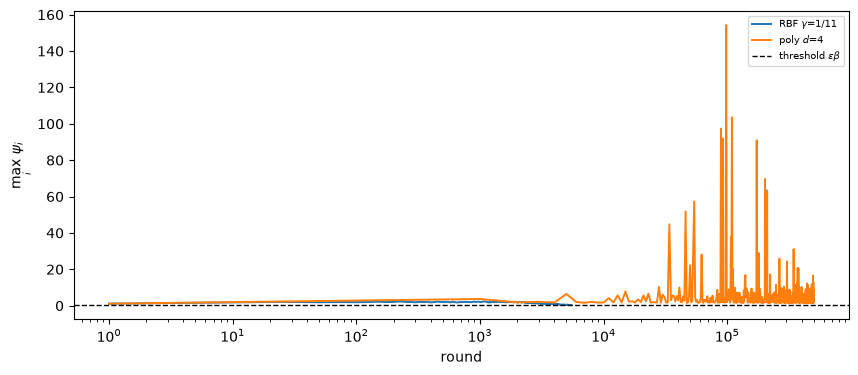

In [9]:
rbf  = CrammerSingerSVM(X_train, y_train, beta=1.1, kernel="rbf", gamma=1/11).fit(
           epsilon=0.3, max_rounds=500_000, trace_every=25)
poly = CrammerSingerSVM(X_train, y_train, beta=1.1, kernel="poly", kern_bias=1.5, gamma=1.0, d=4).fit(
           epsilon=0.3, max_rounds=500_000, trace_every=1000)

fig, ax = plt.subplots(figsize=(10, 4))

for lab, m in [(r"RBF $\gamma$=1/11", rbf), (r"poly $d$=4", poly)]:
    t, v = zip(*m.trace); ax.semilogx(np.maximum(t,1), v, lw=1.4, label=lab)
    
ax.axhline(0.3*1.1, ls="--", c="k", lw=1, label=r"threshold $\epsilon\beta$")
ax.set_xlabel("round"); ax.set_ylabel(r"$\max_i\,\psi_i$"); ax.legend(fontsize=7)

## 10. Cost of duplicate leakage 

In [10]:
Xa, Xb, ya, yb = train_test_split_np(Xd, yd, 0.2, seed=42)
mu, sd = Xa.mean(0), Xa.std(0)
m_dup = CrammerSingerSVM((Xa-mu)/sd, ya, beta=1.1, kernel="rbf", gamma=0.05).fit(epsilon=0.3, max_rounds=500_000)
yp = m_dup.predict((Xb-mu)/sd)

print(f"with duplicates    : {accuracy(yb, yp):.4f}")
print(f"  on leaked rows   : {accuracy(yb[leak], yp[leak]):.4f}")
print(f"  on clean rows    : {accuracy(yb[~leak], yp[~leak]):.4f}")

with duplicates    : 0.5592
  on leaked rows   : 0.5889
  on clean rows    : 0.5479


## 11. Reference

Crammer, K. and Singer, Y., 2001. On the algorithmic implementation of multiclass kernel-based vector machines. Journal of machine learning research, 2(Dec), pp.265-292.